In [39]:
import os
# This tells this specific notebook exactly where to find 'dot.exe'
os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz\bin'

# Now check if it works
import shutil
print(shutil.which('dot')) # This should now print a file path, not 'None'

C:\Program Files (x86)\Graphviz\bin\dot.EXE


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3.0)

20.0

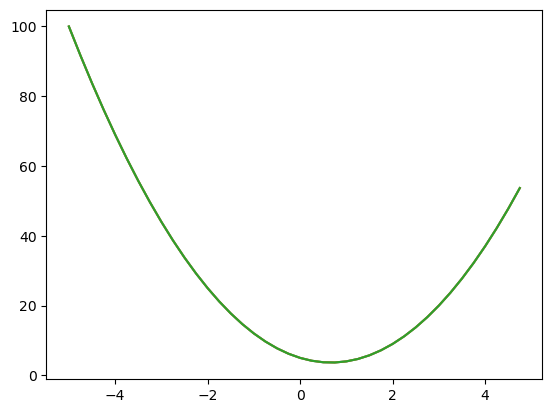

In [14]:
xs=np.arange(-5, 5, 0.25)
ys=f(xs)
plt.plot(xs,ys)
plt.show()

In [25]:
h=0.0000000000001
x=-3.0
(f(x+h)-f(x))/h

-22.026824808563106

In [81]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data=data
        self.grad = 0
        self._prev=set(_children)
        self._op=_op
        self.label=label

    def __repr__(self):
       return f"Value(data={self.data})"
        
    def __add__(self, other):
        out = Value(self.data+other.data, (self,other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data*other.data, (self,other), '*')
        return out

a=Value(2.0, label='a')
b=Value(-3.0, label='b')
c=Value(10.0, label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
f=Value(-2.0, label='f')
L=d*f; L.label='L'
L


Value(data=-8.0)

In [82]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        # dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        dot.node(name=str(id(n)), label = "{%s| data %.4f | grad %.4f   }" % (n.label,n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

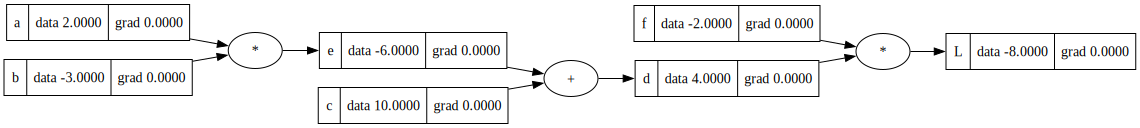

In [83]:
draw_dot(L)

In [80]:
f.grad=4.0
d.grad=-2

In [ ]:
L.grad=1.0